# DINOv2-Small (U2) evaluation on ACDC

This notebook evaluates a trained `DINOv2-Small U2` checkpoint on the `ACDC` validation split.
It includes:
- environment setup for Colab,
- dataset unpacking,
- checkpoint loading,
- metrics + plots,
- ClearML logging.


In [1]:
!pip install -q torchmetrics clearml python-dotenv matplotlib


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 27.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 67.0 MB/s eta 0:00:00


In [2]:
import os
import zipfile
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchmetrics.classification import MulticlassJaccardIndex

from clearml import Task
from google.colab import drive, userdata


In [ ]:
CONFIG = {
    "project_name": "Segmentation_Urban_Scene_CourseWork",
    "task_name": "DinoV2_Small_U2_Eval_ACDC_Val",
    "drive_root": "/content/drive/MyDrive",
    "weights_rel_path": "weights/dinov2-small-U2-cityscapes-acdc-*.ckpt",
    "acdc_zips": [
        "gt_trainval.zip",
        "rgb_anon_trainvaltest.zip",
    ],
    "data_dir": "/content/data/acdc",
    "split": "val",
    "conditions": ["fog", "night", "rain", "snow"],
    "model_name": "dinov2_vits14",
    "num_classes": 19,
    "image_size": (518, 1022),
    "batch_size": 8,
    "num_workers": 2,
    "device": "cuda" if torch.cuda.is_available() else "cpu",
}

CITYSCAPES_CLASSES = [
    "road", "sidewalk", "building", "wall", "fence", "pole", "traffic light",
    "traffic sign", "vegetation", "terrain", "sky", "person", "rider", "car",
    "truck", "bus", "train", "motorcycle", "bicycle"
]

IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

os.environ["CLEARML_API_ACCESS_KEY"] = userdata.get("CLEARML_API_ACCESS_KEY")
os.environ["CLEARML_API_SECRET_KEY"] = userdata.get("CLEARML_API_SECRET_KEY")

task = Task.init(
    project_name=CONFIG["project_name"],
    task_name=CONFIG["task_name"],
    output_uri=False,
)
task.connect(CONFIG)

print(f"Using device: {CONFIG['device']}")


ClearML Task: created new task id=e81ff8ef6cf44dcda01b83d0bfb785fd


/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)


2026-03-29 18:26:47,973 - clearml.Task - INFO - Storing jupyter notebook directly as code
ClearML results page: https://app.clear.ml/projects/588d5d925230490b9f98b1007b4c7fa0/experiments/e81ff8ef6cf44dcda01b83d0bfb785fd/output/log
Using device: cuda


In [4]:
drive.mount("/content/drive")

Path(CONFIG["data_dir"]).mkdir(parents=True, exist_ok=True)

for zip_name in CONFIG["acdc_zips"]:
    zip_path = Path(CONFIG["drive_root"]) / zip_name
    if not zip_path.exists():
        raise FileNotFoundError(f"Zip file not found: {zip_path}")

    print(f"Unpacking {zip_path} -> {CONFIG['data_dir']}")
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(CONFIG["data_dir"])

weights_root = Path(CONFIG["drive_root"])
weights_rel_path = CONFIG["weights_rel_path"]
if any(char in weights_rel_path for char in "*?["):
    candidates = sorted(weights_root.glob(weights_rel_path), key=lambda p: p.stat().st_mtime)
    if not candidates:
        raise FileNotFoundError(f"Checkpoint pattern did not match any files: {weights_root / weights_rel_path}")
    weights_path = candidates[-1]
else:
    weights_path = weights_root / weights_rel_path

if not weights_path.exists():
    raise FileNotFoundError(f"Checkpoint not found: {weights_path}")

print(f"Checkpoint path: {weights_path}")


Mounted at /content/drive
Unpacking /content/drive/MyDrive/gt_trainval.zip -> /content/data/acdc
Unpacking /content/drive/MyDrive/rgb_anon_trainvaltest.zip -> /content/data/acdc
Checkpoint path: /content/drive/MyDrive/weights/dinov2-small-U2-cityscapes-acdc-epoch=01-val_miou=0.7141.ckpt


In [5]:
class ACDCDataset(Dataset):
    def __init__(self, root_dir, split="val", conditions=None, image_size=(518, 1022)):
        self.root_dir = Path(root_dir)
        self.split = split
        self.conditions = conditions or ["fog", "night", "rain", "snow"]
        self.image_size = image_size
        self.items = []

        for condition in self.conditions:
            rgb_root = self.root_dir / "rgb_anon" / condition / split
            gt_root = self.root_dir / "gt" / condition / split
            if not rgb_root.exists() or not gt_root.exists():
                print(f"Skip missing split folder: {condition}/{split}")
                continue

            for image_path in sorted(rgb_root.rglob("*_rgb_anon.png")):
                rel = image_path.relative_to(rgb_root)
                mask_name = image_path.name.replace("_rgb_anon.png", "_gt_labelTrainIds.png")
                mask_path = gt_root / rel.parent / mask_name
                if mask_path.exists():
                    self.items.append(
                        {
                            "image": image_path,
                            "mask": mask_path,
                            "condition": condition,
                            "stem": image_path.stem,
                        }
                    )

        if len(self.items) == 0:
            raise RuntimeError("No ACDC image/mask pairs found. Check dataset path and split.")

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        sample = self.items[idx]
        image = cv2.imread(str(sample["image"]))
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(str(sample["mask"]), 0)

        height, width = self.image_size
        image = cv2.resize(image, (width, height), interpolation=cv2.INTER_LINEAR)
        mask = cv2.resize(mask, (width, height), interpolation=cv2.INTER_NEAREST)

        image = torch.from_numpy(image.transpose(2, 0, 1)).float() / 255.0
        mask = torch.from_numpy(mask.astype(np.int64))
        return {
            "image": image,
            "mask": mask,
            "condition": sample["condition"],
            "stem": sample["stem"],
        }


dataset = ACDCDataset(
    root_dir=CONFIG["data_dir"],
    split=CONFIG["split"],
    conditions=CONFIG["conditions"],
    image_size=CONFIG["image_size"],
)

loader = DataLoader(
    dataset,
    batch_size=CONFIG["batch_size"],
    shuffle=False,
    num_workers=CONFIG["num_workers"],
    pin_memory=True,
)

print(f"ACDC samples: {len(dataset)}")
print(pd.DataFrame(dataset.items)["condition"].value_counts().sort_index())


ACDC samples: 406
condition
fog      100
night    106
rain     100
snow     100
Name: count, dtype: int64


In [6]:
class LinearSegmentationHead(nn.Module):
    def __init__(self, embed_dim=384, num_classes=19, patch_size=14):
        super().__init__()
        self.patch_size = patch_size
        self.linear = nn.Conv2d(embed_dim, num_classes, kernel_size=1)

    def forward(self, x, h, w):
        bsz, _, channels = x.shape
        patch_h = h // self.patch_size
        patch_w = w // self.patch_size
        x = x.reshape(bsz, patch_h, patch_w, channels).permute(0, 3, 1, 2)
        x = self.linear(x)
        x = F.interpolate(x, size=(h, w), mode="bilinear", align_corners=False)
        return x


class DinoV2SegmentationModel(nn.Module):
    def __init__(self, model_name="dinov2_vits14", num_classes=19):
        super().__init__()
        self.backbone = torch.hub.load("facebookresearch/dinov2", model_name)
        self.segmentation_head = LinearSegmentationHead(embed_dim=384, num_classes=num_classes, patch_size=14)

    def _normalize(self, images):
        mean = images.new_tensor(IMAGENET_MEAN).view(1, 3, 1, 1)
        std = images.new_tensor(IMAGENET_STD).view(1, 3, 1, 1)
        return (images - mean) / std

    def forward(self, images):
        _, _, h, w = images.shape
        features = self.backbone.forward_features(self._normalize(images))
        patch_features = features["x_norm_patchtokens"]
        logits = self.segmentation_head(patch_features, h, w)
        return logits


def load_lightning_checkpoint(model, ckpt_path, device):
    ckpt = torch.load(ckpt_path, map_location=device)
    state_dict = ckpt.get("state_dict", ckpt)

    model_state = {}
    for key, value in state_dict.items():
        if key.startswith("backbone.") or key.startswith("segmentation_head."):
            model_state[key] = value

    missing, unexpected = model.load_state_dict(model_state, strict=False)
    print(f"Missing keys: {len(missing)}")
    print(f"Unexpected keys: {len(unexpected)}")

    model.to(device)
    model.eval()
    return model


model = DinoV2SegmentationModel(
    model_name=CONFIG["model_name"],
    num_classes=CONFIG["num_classes"],
)
model = load_lightning_checkpoint(model, str(weights_path), CONFIG["device"])


Downloading: "https://github.com/facebookresearch/dinov2/zipball/main" to /root/.cache/torch/hub/main.zip


/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning:

xFormers is not available (SwiGLU)

/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning:

xFormers is not available (Attention)

/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning:

xFormers is not available (Block)



Downloading: "https://dl.fbaipublicfiles.com/dinov2/dinov2_vits14/dinov2_vits14_pretrain.pth" to /root/.cache/torch/hub/checkpoints/dinov2_vits14_pretrain.pth


100%|██████████| 84.2M/84.2M [00:00<00:00, 272MB/s]


2026-03-29 18:32:31,880 - clearml.model - INFO - Selected model id: 096af8490ce44af1b6986ef1b35ef075
Missing keys: 0
Unexpected keys: 0


In [ ]:
@torch.no_grad()
def evaluate(model, dataloader, num_classes=19, device="cpu"):
    metric_all = MulticlassJaccardIndex(num_classes=num_classes, average="macro", ignore_index=255).to(device)
    metric_per_class = MulticlassJaccardIndex(num_classes=num_classes, average="none", ignore_index=255).to(device)
    condition_metrics = {
        cond: MulticlassJaccardIndex(num_classes=num_classes, average="macro", ignore_index=255).to(device)
        for cond in CONFIG["conditions"]
    }

    total_pixels = 0
    total_correct = 0

    for batch in dataloader:
        images = batch["image"].to(device)
        masks = batch["mask"].to(device)
        conditions = batch["condition"]

        logits = model(images)
        preds = torch.argmax(logits, dim=1)

        metric_all.update(preds, masks)
        metric_per_class.update(preds, masks)

        valid = masks != 255
        total_correct += ((preds == masks) & valid).sum().item()
        total_pixels += valid.sum().item()

        for i, cond in enumerate(conditions):
            condition_metrics[cond].update(preds[i:i + 1], masks[i:i + 1])

    overall_miou = metric_all.compute().item()
    class_iou = metric_per_class.compute().detach().cpu().numpy()
    pixel_acc = total_correct / max(total_pixels, 1)
    condition_miou = {cond: metric.compute().item() for cond, metric in condition_metrics.items()}

    return {
        "overall_miou": overall_miou,
        "pixel_accuracy": pixel_acc,
        "class_iou": class_iou,
        "condition_miou": condition_miou,
    }


results = evaluate(model, loader, num_classes=CONFIG["num_classes"], device=CONFIG["device"])

summary_df = pd.DataFrame(
    {
        "metric": ["mIoU", "Pixel Accuracy"],
        "value": [results["overall_miou"], results["pixel_accuracy"]],
    }
)
condition_df = pd.DataFrame(
    {
        "condition": list(results["condition_miou"].keys()),
        "mIoU": list(results["condition_miou"].values()),
    }
).sort_values("condition")
class_df = pd.DataFrame(
    {
        "class_id": list(range(CONFIG["num_classes"])),
        "class_name": CITYSCAPES_CLASSES,
        "IoU": results["class_iou"],
    }
).sort_values("IoU", ascending=False)

print("Overall metrics")
display(summary_df)
print("\nPer-condition mIoU")
display(condition_df)
print("\nPer-class IoU")
display(class_df)

logger = task.get_logger()
logger.report_table("evaluation", "overall", iteration=0, table_plot=summary_df)
logger.report_table("evaluation", "per_condition", iteration=0, table_plot=condition_df)
logger.report_table("evaluation", "per_class", iteration=0, table_plot=class_df)
logger.report_scalar("evaluation", "mIoU", results["overall_miou"], iteration=0)
logger.report_scalar("evaluation", "pixel_accuracy", results["pixel_accuracy"], iteration=0)


Overall metrics


,metric,value
0,mIoU,0.595675
1,Pixel Accuracy,0.892266



Per-condition mIoU


,condition,mIoU
0,fog,0.705512
1,night,0.397969
2,rain,0.605755
3,snow,0.608723



Per-class IoU


,class_id,class_name,IoU
0,0,road,0.903356
10,10,sky,0.893349
2,2,building,0.823807
16,16,train,0.821874
13,13,car,0.811806
14,14,truck,0.785934
8,8,vegetation,0.784345
15,15,bus,0.680811
1,1,sidewalk,0.636336
6,6,traffic light,0.566490


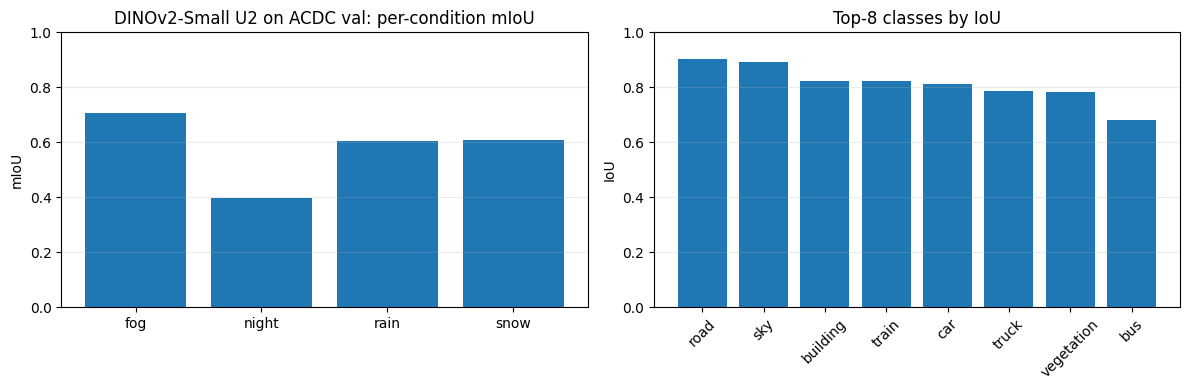

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(condition_df["condition"], condition_df["mIoU"])
axes[0].set_ylim(0, 1)
axes[0].set_ylabel("mIoU")
axes[0].set_title("DINOv2-Small U2 on ACDC val: per-condition mIoU")
axes[0].grid(axis="y", alpha=0.25)

axes[1].bar(class_df.head(8)["class_name"], class_df.head(8)["IoU"])
axes[1].set_ylim(0, 1)
axes[1].set_ylabel("IoU")
axes[1].set_title("Top-8 classes by IoU")
axes[1].tick_params(axis="x", rotation=45)
axes[1].grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()
